In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [99]:
df = pd.read_csv("titanic_data_updated.csv")

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [100]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [101]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [102]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [103]:
X = df.drop(['Survived'], axis=1)

X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


In [104]:
y = df['Survived']
y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: object

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

In [106]:
X_train
display(y_train)

331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: object

In [107]:
X_test
display(y_test)

709    yes
439     no
840     no
720    yes
39     yes
      ... 
433     no
773     no
25     yes
84     yes
10     yes
Name: Survived, Length: 179, dtype: object

In [108]:
X_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

In [109]:
X_test.isnull().sum()

Pclass        0
Sex           0
Age          37
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [110]:
# mean impute

age_mean = X_train['Age'].mean()

X_train['age_mean_impute'] = X_train['Age'].fillna(age_mean)
X_test['age_mean_impute'] = X_test['Age'].fillna(age_mean)

In [111]:
# median impute 

age_median = X_train['Age'].mean()

X_train['age_median_impute'] = X_train['Age'].fillna(age_median)
X_test['age_median_impute'] = X_test['Age'].fillna(age_median)

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_impute,age_median_impute
331,first,male,45.5,0,0,28.5000,C124,S,45.500000,45.500000
733,second,male,23.0,0,0,13.0000,NaN,S,23.000000,23.000000
382,third,male,32.0,0,0,7.9250,NaN,S,32.000000,32.000000
704,third,male,26.0,1,0,7.8542,NaN,S,26.000000,26.000000
813,third,female,6.0,4,2,31.2750,NaN,S,6.000000,6.000000
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S,21.000000,21.000000
270,first,male,NaN,0,0,31.0000,NaN,S,29.498846,29.498846
860,third,male,41.0,2,0,14.1083,NaN,S,41.000000,41.000000
435,first,female,14.0,1,2,120.0000,B96 B98,S,14.000000,14.000000


<Axes: xlabel='age_mean_impute', ylabel='Density'>

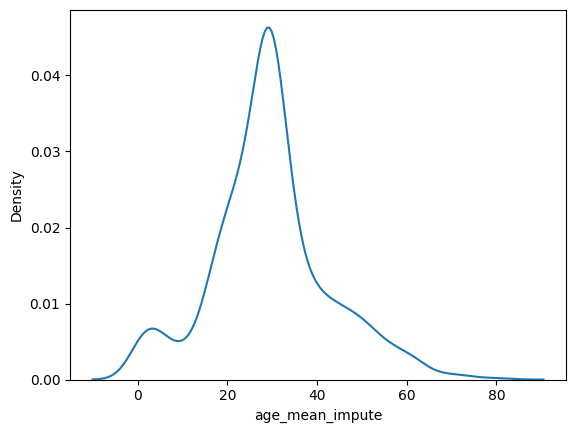

In [112]:
sns.kdeplot(data = X_train, x = 'age_mean_impute')

<Axes: xlabel='age_mean_impute', ylabel='Density'>

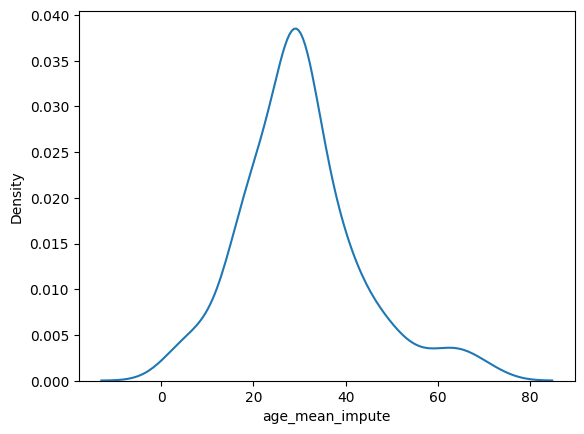

In [113]:
sns.kdeplot(data = X_test, x = 'age_mean_impute')

In [114]:
age_impute = SimpleImputer(missing_values=np.nan, strategy='mean')
age_impute.fit(X_train[['Age']])
X_train['Age'] = age_impute.transform(X_train[['Age']]).ravel()

In [115]:
X_train.isnull().sum()

X_train.drop(['age_mean_impute', 'age_median_impute'], axis=1, inplace=True)

In [116]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.500000,0,0,28.5000,C124,S
733,second,male,23.000000,0,0,13.0000,NaN,S
382,third,male,32.000000,0,0,7.9250,NaN,S
704,third,male,26.000000,1,0,7.8542,NaN,S
813,third,female,6.000000,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,NaN,S
270,first,male,29.498846,0,0,31.0000,NaN,S
860,third,male,41.000000,2,0,14.1083,NaN,S
435,first,female,14.000000,1,2,120.0000,B96 B98,S


In [117]:
X_test['Age'] = age_impute.transform(X_test[['Age']])

X_test.isnull().sum()

Pclass                 0
Sex                    0
Age                    0
SibSp                  0
Parch                  0
Fare                   0
Cabin                134
Embarked               0
age_mean_impute        0
age_median_impute      0
dtype: int64

In [118]:
X_test.drop(['age_mean_impute', 'age_median_impute'], axis=1, inplace=True)

X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,29.498846,1,1,15.2458,NaN,C
439,second,male,31.000000,0,0,10.5000,NaN,S
840,third,male,20.000000,0,0,7.9250,NaN,S
720,second,female,6.000000,0,1,33.0000,NaN,S
39,third,female,14.000000,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,NaN,S
773,third,male,29.498846,0,0,7.2250,NaN,C
25,third,female,38.000000,1,5,31.3875,NaN,S
84,second,female,17.000000,0,0,10.5000,NaN,S


In [119]:
embarked_impute = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

embarked_impute.fit(X_train[['Embarked']])

# transform both train and test data

X_train['Embarked'] = embarked_impute.transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = embarked_impute.transform(X_test[['Embarked']]).ravel()

In [120]:
X_train.isnull().sum()



Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      0
dtype: int64

In [121]:
X_test.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

<Axes: xlabel='Cabin', ylabel='count'>

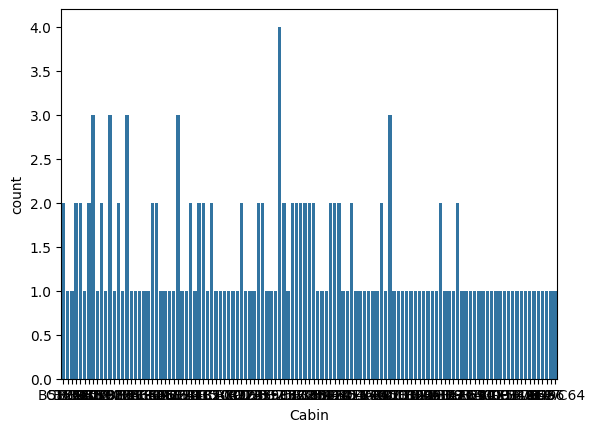

In [122]:
sns.countplot(data= X_train, x=X_train['Cabin'])

In [123]:
cabin_impute = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Missing', add_indicator=True)

cabin_impute.fit(X_train[['Cabin']])

# transform both train and test

X_train[['Cabin', 'cabin_missing_indicator']] = cabin_impute.transform(X_train[['Cabin']])

X_test[['Cabin', 'cabin_missing_indicator']] = cabin_impute.transform(X_test[['Cabin']])

In [124]:
X_train.isnull().sum()

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
cabin_missing_indicator    0
dtype: int64

# Outlier Detection

## Using Z-Score

In [125]:
mean_of_age = X_train['Age'].mean()
std_of_age = X_train['Age'].std()

X_train['zscore_Age'] = (X_train['Age']-mean_of_age)/std_of_age

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00


In [126]:
# 6.4 Outlier handling via Z score Code

outliers_age = X_train[abs(X_train['zscore_Age']) > 3]

print(len(outliers_age))
display(outliers_age)

5


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age
116,third,male,70.5,0,0,7.750,Missing,Q,True,3.155317
745,first,male,70.0,1,1,71.000,B22,S,False,3.116839
630,first,male,80.0,0,0,30.000,A23,S,False,3.886407
851,third,male,74.0,0,0,7.775,Missing,S,True,3.424666
672,second,male,70.0,0,0,10.500,Missing,S,True,3.116839


In [127]:
mean_of_fare = X_train['Fare'].mean()
std_of_fare = X_train['Fare'].std()

X_train['zscore_Fare'] = (X_train['Fare'] - mean_of_fare) / std_of_fare

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00,1.682019


In [128]:
outliers_fare = X_train[abs(X_train['zscore_Fare']) > 3]

print(len(outliers_fare))
display(outliers_fare)

17


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
118,first,male,24.000000,0,1,247.5208,B58 B60,C,False,-4.231736e-01,4.135780
716,first,female,38.000000,0,0,227.5250,C45,C,False,6.542216e-01,3.751020
377,first,male,27.000000,0,2,211.5000,C82,C,False,-1.923032e-01,3.442666
742,first,female,21.000000,2,2,262.3750,B57 B59 B63 B66,C,False,-6.540440e-01,4.421605
380,first,female,42.000000,0,0,227.5250,Missing,C,True,9.620488e-01,3.751020
779,first,female,43.000000,0,1,211.3375,B3,S,False,1.039006e+00,3.439539
730,first,female,29.000000,0,0,211.3375,B5,S,False,-3.838960e-02,3.439539
88,first,female,23.000000,3,2,263.0000,C23 C25 C27,S,False,-5.001304e-01,4.433631
341,first,female,24.000000,3,2,263.0000,C23 C25 C27,S,False,-4.231736e-01,4.433631
557,first,male,29.498846,0,0,227.5250,Missing,C,True,2.734055e-16,3.751020


# Outliers with IQR

In [129]:
# age 

age_Q1 = X_train['Age'].quantile(0.25)
age_Q3 = X_train['Age'].quantile(0.75)

age_IQR = age_Q3 - age_Q1

age_minimum = age_Q1 - 1.5 * age_IQR
age_maximum = age_Q3 + 1.5 * age_IQR

print(age_minimum, age_maximum)

2.5 54.5


In [130]:
age_outlier_IQR = X_train[(X_train['Age']<age_minimum) | (X_train['Age'] > age_maximum)]

print(len(age_outlier_IQR))
display(age_outlier_IQR)

54


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
326,third,male,61.00,0,0,6.2375,Missing,S,True,2.424228,-0.507004
483,third,female,63.00,0,0,9.5875,Missing,S,True,2.578141,-0.442543
7,third,male,2.00,3,1,21.0750,Missing,S,True,-2.116223,-0.221500
305,first,male,0.92,1,2,151.5500,C22 C26,S,False,-2.199336,2.289105
829,first,female,62.00,0,0,80.0000,B28,S,False,2.501185,0.912337
626,second,male,57.00,0,0,12.3500,Missing,Q,True,2.116401,-0.389387
456,first,male,65.00,0,0,26.5500,E38,S,False,2.732055,-0.116150
172,third,female,1.00,1,1,11.1333,Missing,S,True,-2.193180,-0.412799
164,third,male,1.00,4,1,39.6875,Missing,S,True,-2.193180,0.136642
381,third,female,1.00,0,2,15.7417,Missing,C,True,-2.193180,-0.324124


In [131]:
# fare 


fare_Q1 = X_train['Fare'].quantile(0.25)
fare_Q3 = X_train['Fare'].quantile(0.75)

fare_IQR = fare_Q3 - fare_Q1

fare_minimum = max(0, fare_Q1 - 1.5 * fare_IQR)
fare_maximum = fare_Q3 + 1.5 * fare_IQR

print(fare_minimum, fare_maximum)

0 64.3625


In [132]:
fare_outlier_IQR = X_train[(X_train['Fare']<fare_minimum) | (X_train['Fare'] > fare_maximum)]

print(len(fare_outlier_IQR))
display(fare_outlier_IQR)

96


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
118,first,male,24.0,0,1,247.5208,B58 B60,C,False,-0.423174,4.135780
486,first,female,35.0,1,0,90.0000,C93,S,False,0.423351,1.104757
716,first,female,38.0,0,0,227.5250,C45,C,False,0.654222,3.751020
390,first,male,36.0,1,2,120.0000,B96 B98,S,False,0.500308,1.682019
377,first,male,27.0,0,2,211.5000,C82,C,False,-0.192303,3.442666
...,...,...,...,...,...,...,...,...,...,...,...
681,first,male,27.0,0,0,76.7292,D49,C,False,-0.192303,0.849400
385,second,male,18.0,0,0,73.5000,Missing,S,True,-0.884914,0.787264
700,first,female,18.0,1,0,227.5250,C62 C64,C,False,-0.884914,3.751020
435,first,female,14.0,1,2,120.0000,B96 B98,S,False,-1.192742,1.682019


In [133]:
# z score outlier detection is better for age outliers

# z score jader 3 er choto ba shoman shudu matro tader kei amra train e rakhtesi
X_train = X_train[abs(X_train['zscore_Age']) <= 3]

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00,1.682019


In [134]:
minimum_zscore_fare = X_train[abs(X_train['zscore_Fare']) <= 3]['Fare'].max()

print(minimum_zscore_fare)

164.8667


In [135]:
# iqr is better for fare

X_train['Fare'] = X_train['Fare'].clip(fare_minimum, fare_maximum)

X_train['Fare'].max()

C:\Users\Tuhin Ahmed\AppData\Local\Temp\ipykernel_556\755125540.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Fare'] = X_train['Fare'].clip(fare_minimum, fare_maximum)


np.float64(64.3625)

In [136]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,zscore_Age,zscore_Fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,-1.192742e+00,1.682019


In [137]:
X_train.drop(['zscore_Age', 'zscore_Fare'], axis=1, inplace=True)

X_train

C:\Users\Tuhin Ahmed\AppData\Local\Temp\ipykernel_556\906852025.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(['zscore_Age', 'zscore_Fare'], axis=1, inplace=True)


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
331,first,male,45.500000,0,0,28.5000,C124,S,False
733,second,male,23.000000,0,0,13.0000,Missing,S,True
382,third,male,32.000000,0,0,7.9250,Missing,S,True
704,third,male,26.000000,1,0,7.8542,Missing,S,True
813,third,female,6.000000,4,2,31.2750,Missing,S,True
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True
270,first,male,29.498846,0,0,31.0000,Missing,S,True
860,third,male,41.000000,2,0,14.1083,Missing,S,True
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False
